# Exploratory Data Analysis
In this notebook, we explore the training data `train_data_ner.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the training data
df_train = pd.read_csv('../nlp_d2_data/train_data_ner.csv')
display(df_train.head())


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.star

AttributeError: _ARRAY_API not found

,sentence_id,words,tags
0,0,Thousands,O
1,0,of,O
2,0,demonstrators,O
3,0,have,O
4,0,marched,O


## Sentence Lengths

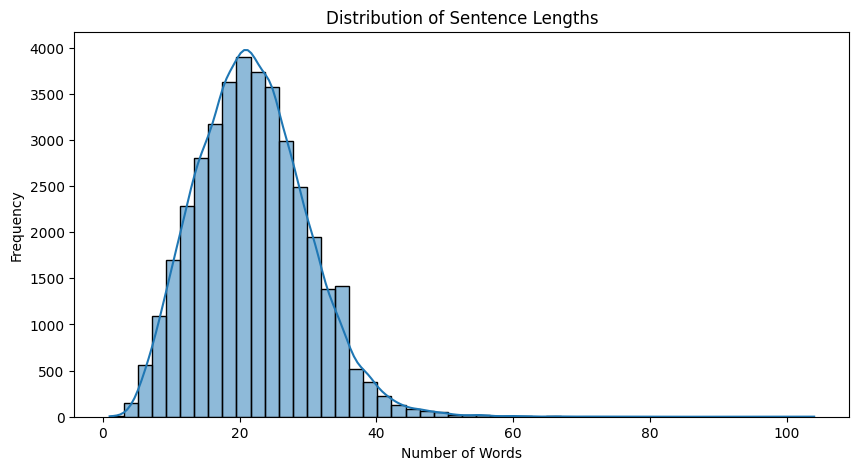

Max sentence length: 104
Mean sentence length: 21.87


In [2]:
sentence_lengths = df_train.groupby('sentence_id').size()

plt.figure(figsize=(10, 5))
sns.histplot(sentence_lengths, bins=50, kde=True)
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

print(f"Max sentence length: {sentence_lengths.max()}")
print(f"Mean sentence length: {sentence_lengths.mean():.2f}")

## Tag Distribution
Let's look at the distribution of Named Entity Tags, excluding the 'O' (Outside) tag which is typically the majority class.

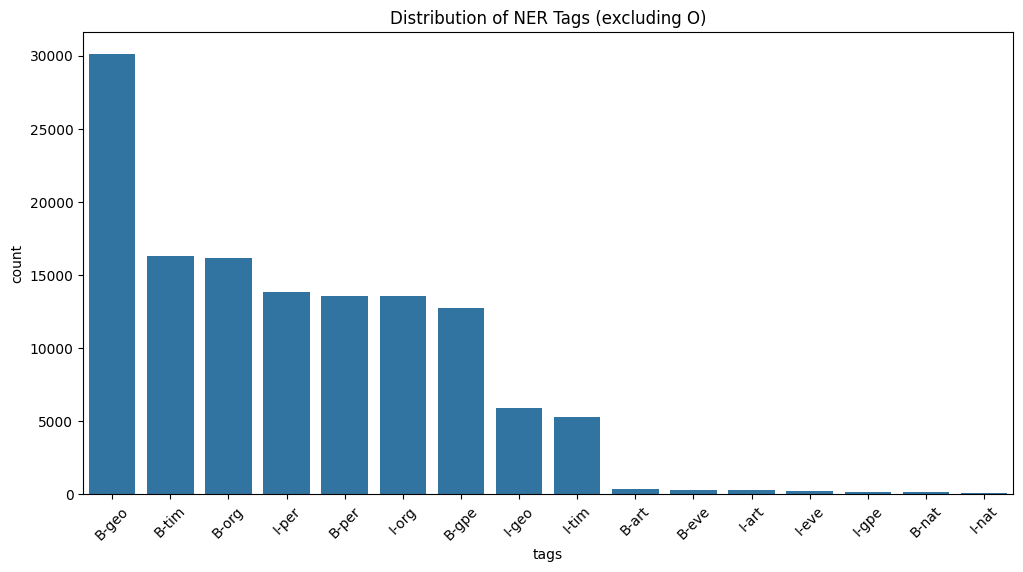

In [3]:
tags_no_O = df_train[df_train['tags'] != 'O']
plt.figure(figsize=(12, 6))
sns.countplot(data=tags_no_O, x='tags', order=tags_no_O['tags'].value_counts().index)
plt.title('Distribution of NER Tags (excluding O)')
plt.xticks(rotation=45)
plt.show()